# PFAS Nephrotoxicity Classification Analysis

This notebook classifies PFAS (Per- and Polyfluoroalkyl Substances) compounds by nephrotoxicity severity using machine learning models trained on molecular and quantum-chemical descriptors.

## Project Overview

- **Goal**: Predict nephrotoxicity class (1-4) for PFAS compounds across species
- **Dataset**: 79 observations of 9 PFAS compounds across 4 species (Mouse, Rat, Monkey, Human)
- **Methods**: K-Nearest Neighbors, XGBoost, Decision Tree

## Toxicity Classes
- **Class 1**: Lowest toxicity
- **Class 2**: Low-moderate toxicity
- **Class 3**: Moderate-high toxicity
- **Class 4**: Highest toxicity

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.tree import plot_tree
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline

## 2. Load and Explore the Dataset

In [2]:
data = pd.read_excel('../data/data.xlsx')
data = pd.DataFrame(data)

print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Dataset shape: (79, 23)
Columns: ['PREFERRED_NAME', 'SMILES', 'Species', 'Sex', 'AVERAGE_MASS', 'ProxTubDiam', 'LogP_pred', 'GlomTotSA_ProxTubTotVol_ratio', 'LogP', 'TPSA', 'SASA', 'EHOMO', 'ELUMO', 'Gap', 'Hardness', 'Softness', 'Mu', 'Omega', 'HF_Energy', 'RMSD', 'ZeroPoint', 'Dipole', 'ClassPredFull']


,PREFERRED_NAME,SMILES,Species,Sex,AVERAGE_MASS,ProxTubDiam,LogP_pred,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,...,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole,ClassPredFull
0,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Human,Male,-0.577936,1.654466,-0.160634,1.710562,3.266,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
1,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Rat,Male,-0.577936,-0.552567,-0.160634,-0.320640,3.266,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
2,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Monkey,Female,-0.577936,0.088924,-0.160634,-0.757934,3.266,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
3,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Rat,Male,-0.577936,-0.552567,-0.160634,-0.320640,3.266,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
4,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Monkey,Male,-0.577936,0.088924,-0.160634,-0.757934,3.266,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2


In [3]:
data.info()
print()
print("Missing values:")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PREFERRED_NAME                 79 non-null     object 
 1   SMILES                         79 non-null     object 
 2   Species                        79 non-null     object 
 3   Sex                            79 non-null     object 
 4   AVERAGE_MASS                   79 non-null     float64
 5   ProxTubDiam                    79 non-null     float64
 6   LogP_pred                      79 non-null     float64
 7   GlomTotSA_ProxTubTotVol_ratio  79 non-null     float64
 8   LogP                           79 non-null     float64
 9   TPSA                           79 non-null     float64
 10  SASA                           79 non-null     float64
 11  EHOMO                          79 non-null     float64
 12  ELUMO                          79 non-null     float

## 3. Data Preprocessing

In [4]:
data['Sex'] = data['Sex'].map({'Female': 0, 'Male': 1})
data['Species'] = data['Species'].map({'Mouse': 1, 'Rat': 2, 'Monkey': 3, 'Human': 4})

print("Unique compounds:", data['PREFERRED_NAME'].unique())
print()
print("Class distribution:")
print(data['ClassPredFull'].value_counts())

Unique compounds: ['GenX' 'Perfluoroheptanoic acid' 'Perfluorooctanoic acid'
 'Perfluorooctanesulfonic acid' 'Perfluorobutanesulfonic acid'
 'Perfluorohexanesulfonic acid' 'Perfluorononanoic acid'
 'Perfluorobutanoic acid' 'Perfluorodecanoic acid']

Class distribution:
ClassPredFull
3    27
2    21
4    16
1    15
Name: count, dtype: int64


### Class Distribution Visualization

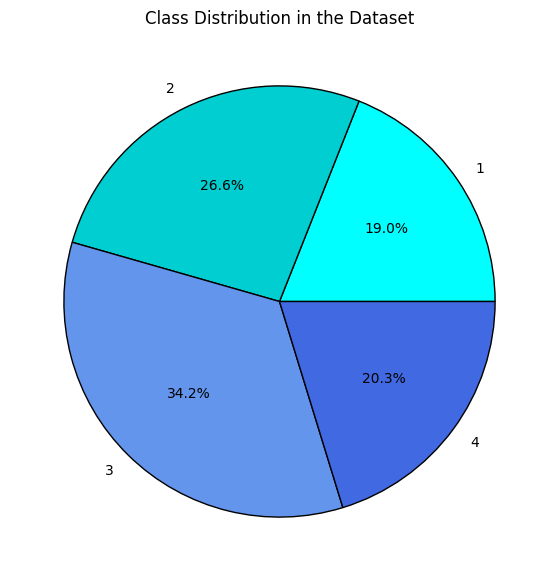

In [5]:
class_counts = data['ClassPredFull'].value_counts().sort_index()
colors = ['cyan', 'darkturquoise', 'cornflowerblue', 'royalblue']

plt.figure(figsize=(10, 7))
plt.pie(
    class_counts.values,
    labels=[str(c) for c in class_counts.index],
    colors=colors,
    autopct='%1.1f%%',
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)
plt.title('Class Distribution in the Dataset')
plt.show()

## 4. Train/Test Split and Feature Scaling

In [6]:
train = data.iloc[0:57, :]
X_train = train.iloc[:, 2:-1].copy()
y_train = train.iloc[:, -1].copy()

test = data.iloc[57:, :]
X_test = test.iloc[:, 2:-1].copy()
y_test = test.iloc[:, -1].copy()

X_train.columns = train.columns[2:22]

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Features: {X_train.shape[1]}")

Training set: 57 samples
Test set: 22 samples
Features: 20


In [7]:
scale_cols_train = X_train.iloc[:, 6:22]
scaler = StandardScaler()
X_train_scale = pd.DataFrame(
    scaler.fit_transform(scale_cols_train),
    columns=scale_cols_train.columns
)

his_data = X_train[['Sex', 'Species', 'ProxTubDiam', 'GlomTotSA_ProxTubTotVol_ratio']]
X_train_ready = pd.concat([his_data.reset_index(drop=True), X_train_scale], axis=1)

scale_cols_test = X_test.iloc[:, 6:22]
X_test_scale = pd.DataFrame(
    scaler.transform(scale_cols_test),
    columns=scale_cols_test.columns
)

his_data_test = X_test[['Sex', 'Species', 'ProxTubDiam', 'GlomTotSA_ProxTubTotVol_ratio']]
X_test_ready = pd.concat([his_data_test.reset_index(drop=True), X_test_scale], axis=1)

X_train_ready.head()

,Sex,Species,ProxTubDiam,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole
0,1,4,1.654466,1.710562,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
1,1,2,-0.552567,-0.320640,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
2,0,3,0.088924,-0.757934,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
3,1,2,-0.552567,-0.320640,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
4,1,3,0.088924,-0.757934,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437


## 5. Feature Correlation and Selection

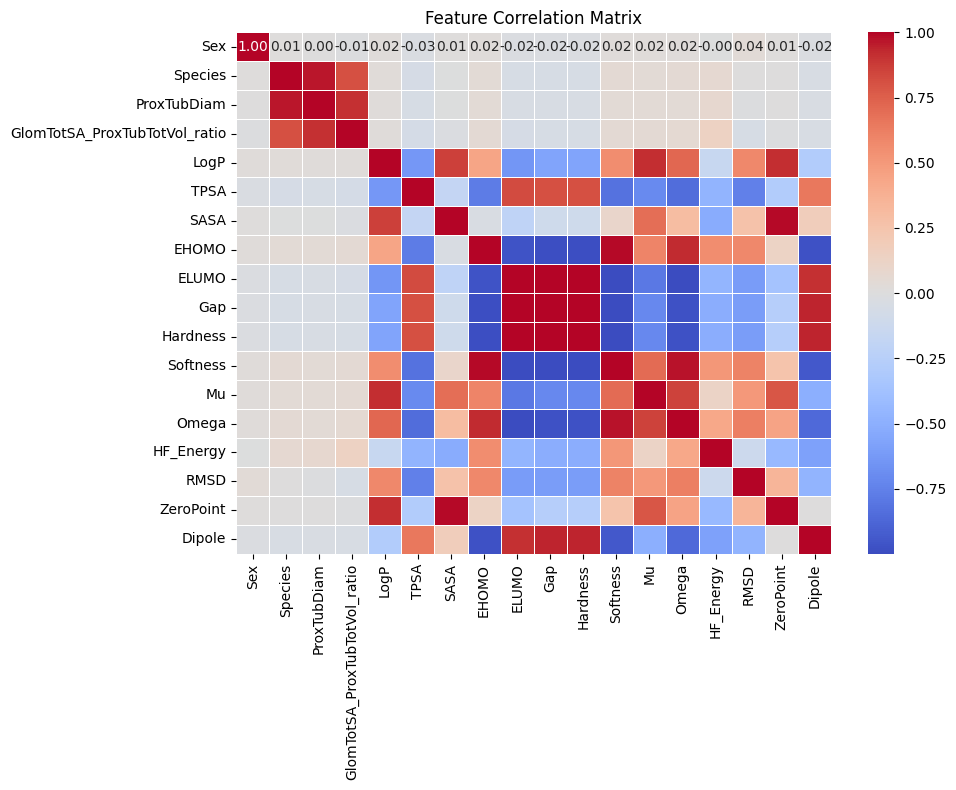

In [8]:
corr_matrix = X_train_ready.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
matrix = pd.DataFrame(
    np.triu(corr_matrix, k=1),
    columns=corr_matrix.columns,
    index=corr_matrix.index
)
to_drop = [col for col in matrix.columns if any(matrix[col] > 0.90)]
print(f"Highly correlated features to drop: {to_drop}")

selected_columns = ['Sex', 'Species', 'LogP', 'SASA', 'Gap', 'HF_Energy']
X_train = X_train_ready[selected_columns].copy()
X_test = X_test_ready[selected_columns].copy()

print(f"Selected features: {selected_columns}")
X_train.head()

Highly correlated features to drop: ['ProxTubDiam', 'GlomTotSA_ProxTubTotVol_ratio', 'Gap', 'Hardness', 'Softness', 'Mu', 'Omega', 'ZeroPoint', 'Dipole']
Selected features: ['Sex', 'Species', 'LogP', 'SASA', 'Gap', 'HF_Energy']


,Sex,Species,LogP,SASA,Gap,HF_Energy
0,1,4,-0.623538,-0.74643,-0.638315,0.327536
1,1,2,-0.623538,-0.74643,-0.638315,0.327536
2,0,3,-0.623538,-0.74643,-0.638315,0.327536
3,1,2,-0.623538,-0.74643,-0.638315,0.327536
4,1,3,-0.623538,-0.74643,-0.638315,0.327536


## 6. Machine Learning Models
1. **K-Nearest Neighbors (KNN)**
2. **XGBoost**
3. **Decision Tree**

In [10]:
def evaluate_model(model_name, y_train, y_pred_train, y_test, y_pred_test):
    print(f"--- {model_name} ---")
    print(f"Accuracy  (train): {metrics.accuracy_score(y_train, y_pred_train):.3f}")
    print(f"Accuracy  (test):  {metrics.accuracy_score(y_test, y_pred_test):.3f}")
    print(f"Precision (train): {metrics.precision_score(y_train, y_pred_train, average='weighted'):.3f}")
    print(f"Precision (test):  {metrics.precision_score(y_test, y_pred_test, average='weighted'):.3f}")
    print(f"Recall    (train): {metrics.recall_score(y_train, y_pred_train, average='weighted'):.3f}")
    print(f"Recall    (test):  {metrics.recall_score(y_test, y_pred_test, average='weighted'):.3f}")
    print(f"F1-Score  (train): {metrics.f1_score(y_train, y_pred_train, average='weighted'):.3f}")
    print(f"F1-Score  (test):  {metrics.f1_score(y_test, y_pred_test, average='weighted'):.3f}")
    print()


def plot_confusion_matrices(y_train, y_pred_train, y_test, y_pred_test, model_name):
    labels = ['1', '2', '3', '4']
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    metrics.ConfusionMatrixDisplay(
        confusion_matrix=metrics.confusion_matrix(y_train, y_pred_train),
        display_labels=labels
    ).plot(ax=axes[0], cmap=plt.cm.Blues)
    axes[0].set_title(f'{model_name} - Train Set')

    metrics.ConfusionMatrixDisplay(
        confusion_matrix=metrics.confusion_matrix(y_test, y_pred_test),
        display_labels=labels
    ).plot(ax=axes[1], cmap=plt.cm.Blues)
    axes[1].set_title(f'{model_name} - Test Set')

    plt.tight_layout()
    plt.show()

### 6.1 K-Nearest Neighbors

--- KNN (k=3) ---
Accuracy  (train): 0.947
Accuracy  (test):  0.545
Precision (train): 0.954
Precision (test):  0.591
Recall    (train): 0.947
Recall    (test):  0.545
F1-Score  (train): 0.947
F1-Score  (test):  0.550



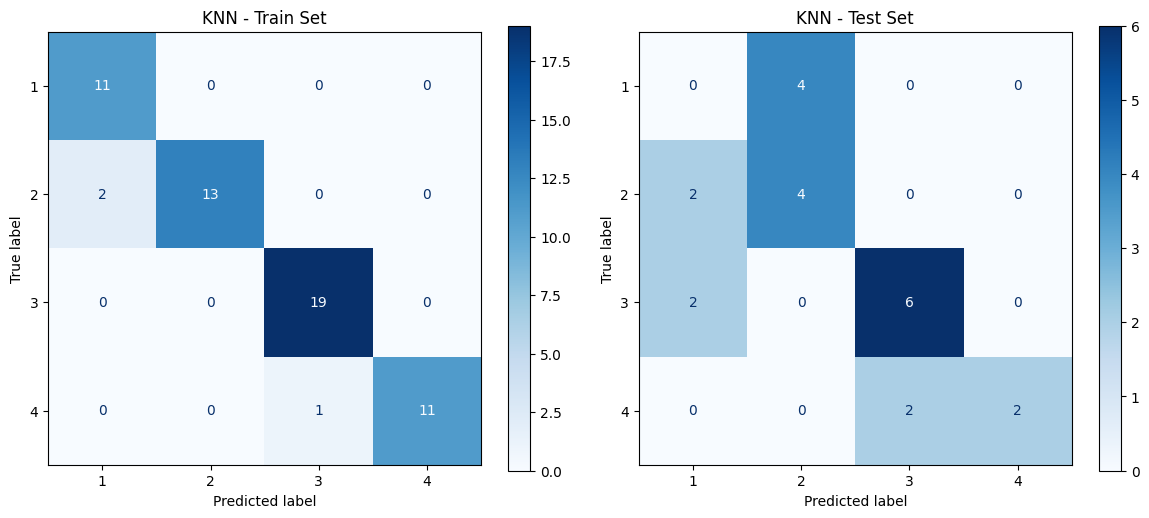

In [11]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_pred_train_knn = knn.predict(X_train)

evaluate_model('KNN (k=3)', y_train, y_pred_train_knn, y_test, y_pred_knn)
plot_confusion_matrices(y_train, y_pred_train_knn, y_test, y_pred_knn, 'KNN')

### 6.2 XGBoost

--- XGBoost ---
Accuracy  (train): 0.895
Accuracy  (test):  0.909
Precision (train): 0.899
Precision (test):  0.927
Recall    (train): 0.895
Recall    (test):  0.909
F1-Score  (train): 0.895
F1-Score  (test):  0.905



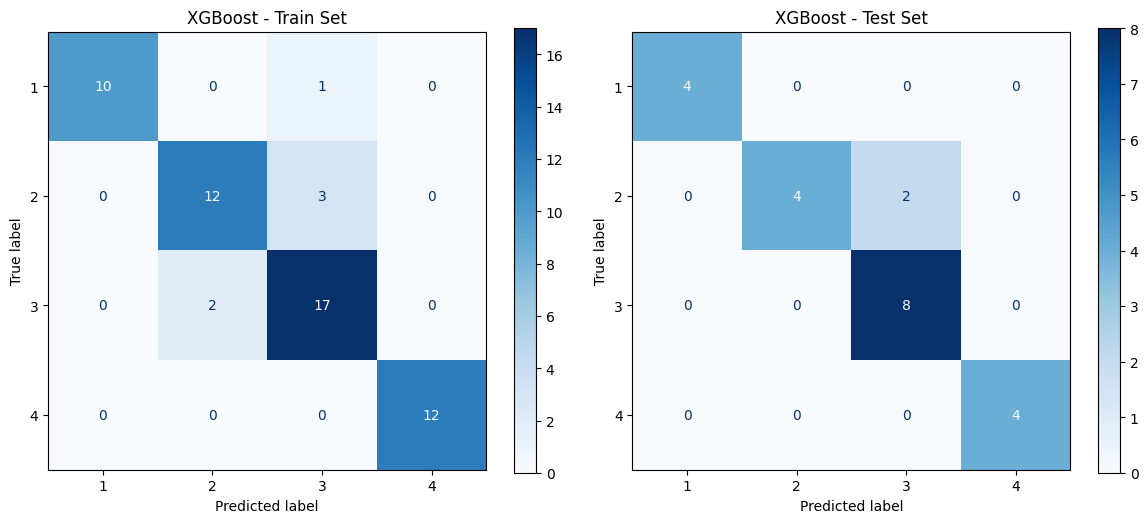

In [12]:
y_train_xgb = y_train - y_train.min()

xgb = XGBClassifier(
    n_estimators=10,
    learning_rate=0.1,
    max_depth=3
)
xgb.fit(X_train, y_train_xgb)

y_pred_xgb = xgb.predict(X_test) + y_train.min()
y_pred_train_xgb = xgb.predict(X_train) + y_train.min()

evaluate_model('XGBoost', y_train, y_pred_train_xgb, y_test, y_pred_xgb)
plot_confusion_matrices(y_train, y_pred_train_xgb, y_test, y_pred_xgb, 'XGBoost')

### 6.3 Decision Tree

--- Decision Tree ---
Accuracy  (train): 0.702
Accuracy  (test):  0.909
Precision (train): 0.700
Precision (test):  0.927
Recall    (train): 0.702
Recall    (test):  0.909
F1-Score  (train): 0.690
F1-Score  (test):  0.905



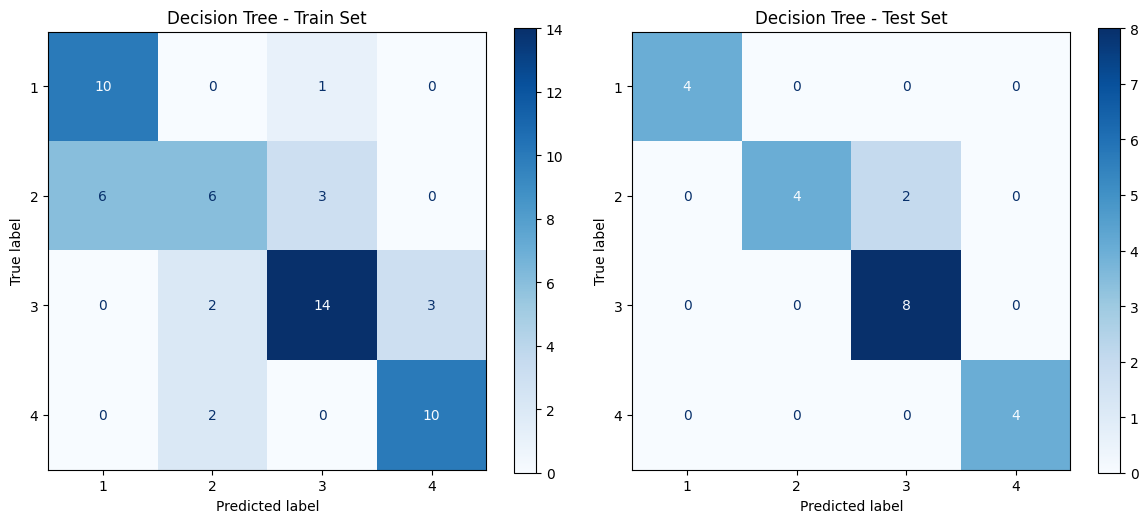

In [13]:
dt = tree.DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    min_samples_split=3,
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_train_dt = dt.predict(X_train)

evaluate_model('Decision Tree', y_train, y_pred_train_dt, y_test, y_pred_dt)
plot_confusion_matrices(y_train, y_pred_train_dt, y_test, y_pred_dt, 'Decision Tree')

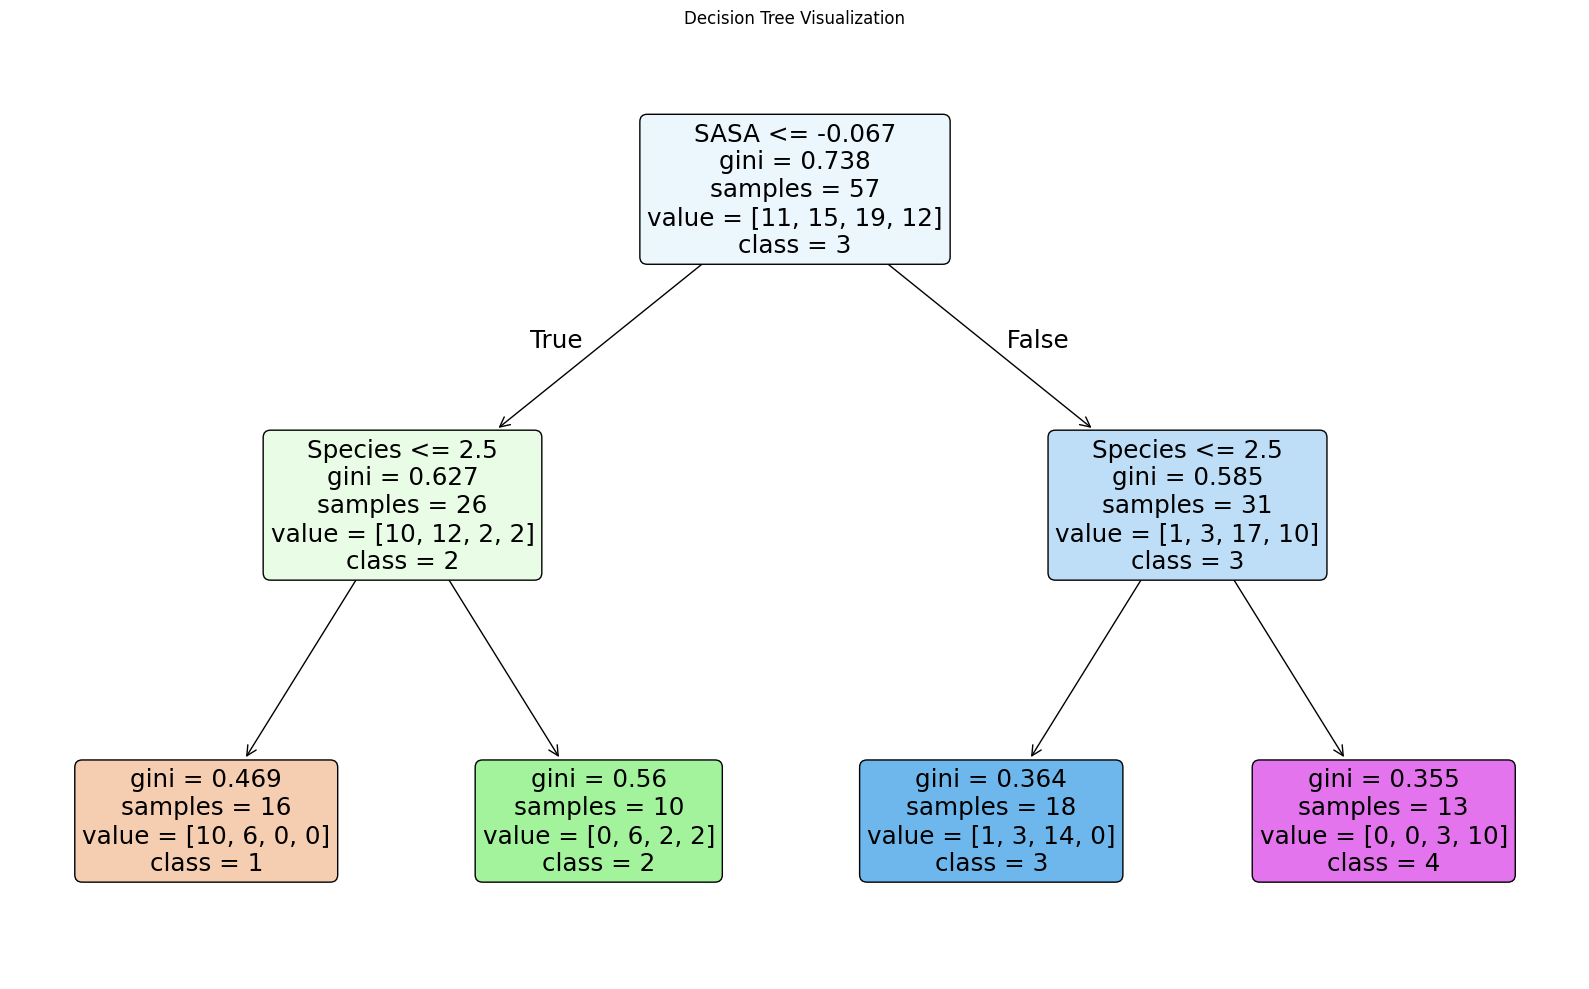

In [14]:
plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['1', '2', '3', '4'],
    filled=True,
    rounded=True
)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

## 7. Feature Importance

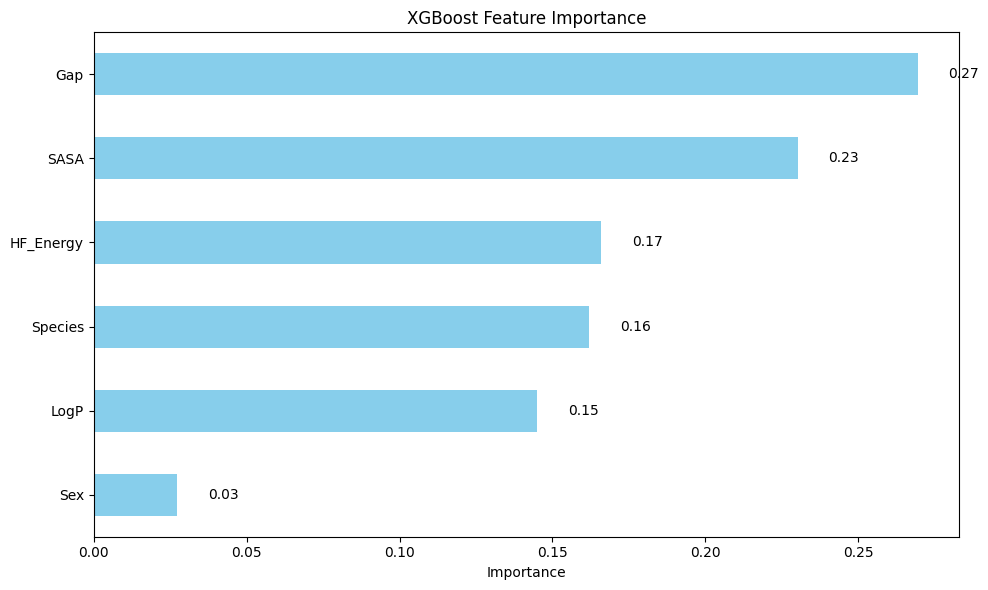

In [15]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = importances.plot(kind='barh', color='skyblue')
for i, v in enumerate(importances):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Model Comparison

In [16]:
comparison = pd.DataFrame({
    'Model': ['KNN', 'XGBoost', 'Decision Tree'],
    'Accuracy (test)': [
        metrics.accuracy_score(y_test, y_pred_knn),
        metrics.accuracy_score(y_test, y_pred_xgb),
        metrics.accuracy_score(y_test, y_pred_dt)
    ],
    'F1-Score (test)': [
        metrics.f1_score(y_test, y_pred_knn, average='weighted'),
        metrics.f1_score(y_test, y_pred_xgb, average='weighted'),
        metrics.f1_score(y_test, y_pred_dt, average='weighted')
    ]
}).round(3)

print(comparison.to_string(index=False))

        Model  Accuracy (test)  F1-Score (test)
          KNN            0.545            0.550
      XGBoost            0.909            0.905
Decision Tree            0.909            0.905


## 9. Save Results

In [17]:
combined_preds = pd.concat([
    pd.Series(y_pred_train_xgb),
    pd.Series(y_pred_xgb)
], ignore_index=True)

output_path = '../results/predictions.xlsx'
pd.DataFrame({'Predictions': combined_preds}).to_excel(output_path, index=False)
comparison.to_excel('../results/model_comparison.xlsx', index=False)

print(f"Predictions saved to: {output_path}")
print(f"Model comparison saved to: ../results/model_comparison.xlsx")

Predictions saved to: ../results/predictions.xlsx
Model comparison saved to: ../results/model_comparison.xlsx
